In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor,RandomForestRegressor,StackingRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
import pickle
df=pd.read_csv(r'/content/Arsenal.csv')
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/Arsenal.csv'

In [ ]:
df.isna().sum()

,0
Date,0
Opponent,0
Is_Home,0
Result,0
Goals,0
Opponent_Goals,0
Possession,0
Shots,0
Shots_On_Target,0
Passes_Completed,0


In [ ]:
df.dtypes

,0
Date,object
Opponent,object
Is_Home,int64
Result,int64
Goals,int64
Opponent_Goals,int64
Possession,int64
Shots,int64
Shots_On_Target,int64
Passes_Completed,int64


In [ ]:
dff=df.copy()
dff=dff.drop(columns=['Date','Opponent','Result','Month','Day_of_Week'])
dff

,Is_Home,Goals,Opponent_Goals,Possession,Shots,Shots_On_Target,Passes_Completed,Pass_Accuracy,Corners,Crosses,...,Opponent_Passes_Completed,Opponent_Pass_Accuracy,Opponent_Corners,Opponent_Crosses,Opponent_Fouls,Opponent_Offsides,Shot_Efficiency,Season,Last5_Avg_Goals,Last5_Win_Rate
0,1,1,2,55,12,5,425,80,4,2,...,399,81,5,3,15,2,0.416667,2013,1.000000,0.00
1,1,1,3,64,15,4,457,87,4,4,...,216,71,3,2,19,1,0.266667,2013,1.000000,0.00
2,0,3,0,60,13,7,451,84,6,2,...,350,79,5,2,15,1,0.538462,2013,1.666667,0.33
3,0,3,1,54,19,9,496,87,8,9,...,421,87,1,1,10,3,0.473684,2013,2.000000,0.50
4,1,2,0,65,14,6,460,86,2,4,...,350,79,3,4,16,1,0.428571,2013,2.000000,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,1,2,2,51,9,7,424,87,5,3,...,406,87,4,2,9,1,0.777778,2025,2.000000,0.40
695,1,1,0,41,12,4,294,84,5,5,...,446,87,4,4,13,1,0.333333,2025,2.200000,0.20
696,1,2,1,51,17,4,431,90,5,8,...,408,86,4,4,10,0,0.235294,2025,2.600000,0.40
697,0,1,1,70,14,5,398,87,8,4,...,130,69,3,2,17,0,0.357143,2025,1.400000,0.60


In [ ]:
df.corr(numeric_only=True)

,Is_Home,Result,Goals,Opponent_Goals,Possession,Shots,Shots_On_Target,Passes_Completed,Pass_Accuracy,Corners,...,Opponent_Corners,Opponent_Crosses,Opponent_Fouls,Opponent_Offsides,Shot_Efficiency,Season,Month,Day_of_Week,Last5_Avg_Goals,Last5_Win_Rate
Is_Home,1.000000,0.197294,0.142916,-0.144721,0.081161,0.289605,0.242021,0.103897,0.126984,0.245670,...,-0.136732,-0.123895,0.032399,-0.082860,0.066880,-0.006536,0.000330,0.010333,0.065748,-0.004580
Result,0.197294,1.000000,0.651010,-0.642573,0.085800,0.288525,0.444107,0.139030,0.144353,0.092377,...,-0.118919,0.023817,-0.133480,-0.042799,0.314657,-0.001288,0.031550,-0.006718,0.354316,0.036230
Goals,0.142916,0.651010,1.000000,-0.173173,0.103064,0.327228,0.602450,0.165132,0.225864,0.057783,...,-0.141609,-0.052514,-0.176706,-0.055974,0.448125,0.021398,0.026471,-0.008077,0.465018,-0.025122
Opponent_Goals,-0.144721,-0.642573,-0.173173,1.000000,-0.145331,-0.172029,-0.179441,-0.178095,-0.149942,-0.120360,...,0.119765,0.030775,0.104098,0.025464,-0.060870,-0.028576,0.006891,0.007703,-0.118679,-0.041725
Possession,0.081161,0.085800,0.103064,-0.145331,1.000000,0.491720,0.287438,0.848190,0.694816,0.437080,...,-0.406227,-0.255375,-0.032311,0.049999,-0.152704,0.014498,0.005001,-0.034289,0.063168,-0.014083
Shots,0.289605,0.288525,0.327228,-0.172029,0.491720,1.000000,0.697077,0.453894,0.432942,0.516468,...,-0.361988,-0.221638,-0.110643,-0.021382,-0.112936,0.021507,0.014805,0.018016,0.140128,0.011985
Shots_On_Target,0.242021,0.444107,0.602450,-0.179441,0.287438,0.697077,1.000000,0.330805,0.332122,0.309026,...,-0.256622,-0.109977,-0.111740,-0.026600,0.565408,-0.065973,0.018560,0.002360,0.291180,0.034123
Passes_Completed,0.103897,0.139030,0.165132,-0.178095,0.848190,0.453894,0.330805,1.000000,0.809928,0.292097,...,-0.410746,-0.262091,-0.135216,0.003890,-0.054706,-0.089095,0.013793,-0.070029,0.129283,0.020562
Pass_Accuracy,0.126984,0.144353,0.225864,-0.149942,0.694816,0.432942,0.332122,0.809928,1.000000,0.290478,...,-0.424483,-0.315571,-0.133651,-0.117414,-0.039851,0.136554,0.051836,-0.075815,0.136922,0.006583
Corners,0.245670,0.092377,0.057783,-0.120360,0.437080,0.516468,0.309026,0.292097,0.290478,1.000000,...,-0.256752,-0.179970,-0.041052,-0.030954,-0.106397,0.046866,0.019197,-0.022547,0.023267,0.008819


<Axes: >

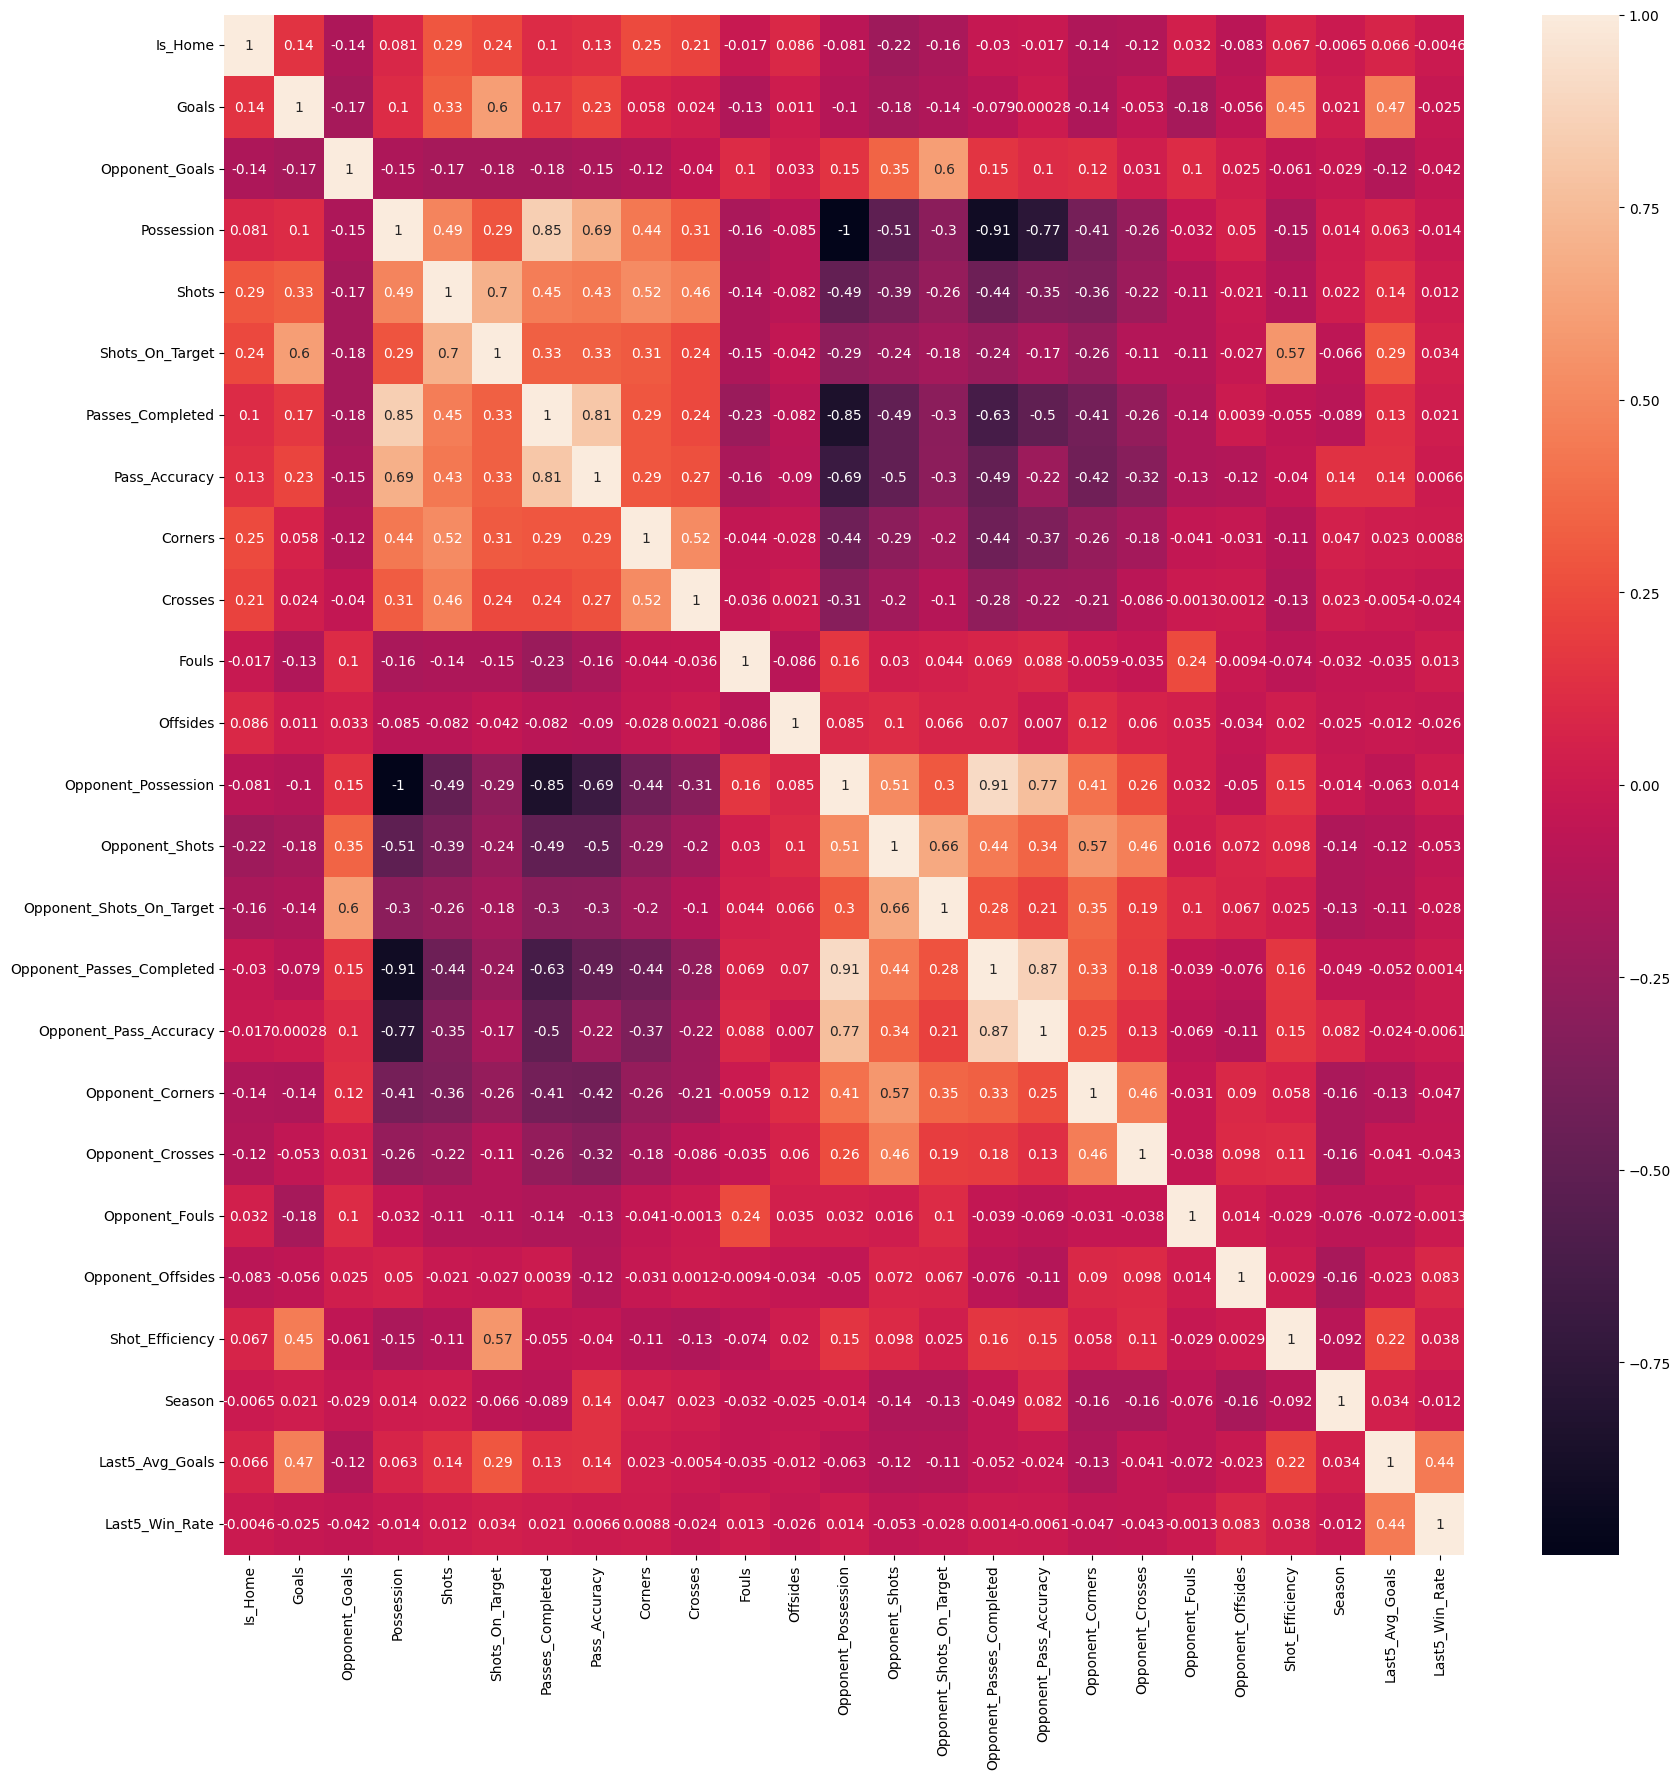

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(dff.corr(),annot=True)

In [ ]:
dff.drop(columns=['Crosses','Offsides','Opponent_Crosses','Opponent_Offsides','Season','Last5_Avg_Goals','Last5_Win_Rate'],inplace=True)

In [ ]:
dff

,Is_Home,Goals,Opponent_Goals,Possession,Shots,Shots_On_Target,Passes_Completed,Pass_Accuracy,Corners,Fouls,Opponent_Possession,Opponent_Shots,Opponent_Shots_On_Target,Opponent_Passes_Completed,Opponent_Pass_Accuracy,Opponent_Corners,Opponent_Fouls,Shot_Efficiency
0,1,1,2,55,12,5,425,80,4,12,45,12,6,399,81,5,15,0.416667
1,1,1,3,64,15,4,457,87,4,15,36,10,5,216,71,3,19,0.266667
2,0,3,0,60,13,7,451,84,6,14,40,6,2,350,79,5,15,0.538462
3,0,3,1,54,19,9,496,87,8,9,46,16,7,421,87,1,10,0.473684
4,1,2,0,65,14,6,460,86,2,16,35,6,4,350,79,3,16,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,1,2,2,51,9,7,424,87,5,9,49,13,5,406,87,4,9,0.777778
695,1,1,0,41,12,4,294,84,5,10,59,8,2,446,87,4,13,0.333333
696,1,2,1,51,17,4,431,90,5,2,49,9,3,408,86,4,10,0.235294
697,0,1,1,70,14,5,398,87,8,13,30,5,2,130,69,3,17,0.357143


In [ ]:
x=dff.drop(columns=['Goals','Opponent_Goals'])
y=dff[['Goals','Opponent_Goals']]
x.ndim

2

In [ ]:
for i in x.columns:
  print(i)
  print(x[i].unique())

Is_Home
[1 0]
Possession
[55 64 60 54 65 43 69 50 52 56 45 62 49 67 44 48 61 66 53 68 59 47 73 57
 21 33 41 58 70 51 76 46 71 36 42 35 72 75 74 37 38 27 31 63 40 34 39 26
 77 30 29 32 20 22 80 82 78 81 28 23]
Shots
[12 15 13 19 14 17  8 20  6 10  9 11  3  7 29 28 22 18  5 25 24 16 32 23
 21 27 26 36 30 33  4  2  1 31 35]
Shots_On_Target
[ 5  4  7  9  6  2 11  3  1  8  0 12 13 10 15 17 14 16]
Passes_Completed
[425 457 451 496 460 305 588 426 459 420 399 462 485 560 375 590 401 522
 441 387 452 480 722 322 378 367 479 448 556 501 592 630 530 389 726 438
 470 158 627 473 234 252 393 605 410 517 533 502 519 557 525 613 546 534
 541 531 640 342 383 737 544 616 542 382 412 352 416 445 374 467 381 249
 195 492 427 275 465 270 474 264 464 321 407 403 489 664 340 400 571 746
 491 691 324 717 576 432 510 471 450 520 379 481 478 564 712 417 280 285
 456 313 551 207 449 580 385 266 344 547 618 355 440 300 487 453 398 475
 271 386 521 439 578 584 289 536 295 623 320 360 681 651 641 550 593 273
 539

In [ ]:
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
x_tr,x_te,y_tr,y_te=train_test_split(x_scaled,y,train_size=0.70,random_state=11)

In [ ]:
x_tr.shape

(489, 16)

In [ ]:
y_tr.shape

(489, 2)

In [ ]:
x_te.shape

(210, 16)

In [ ]:
models=[KNeighborsRegressor(),DecisionTreeRegressor(random_state=11),RandomForestRegressor(random_state=11),LinearRegression()]
r=[]
for i in models:
  i.fit(x_tr,y_tr)
  y_pred=i.predict(x_te)
  r.append(r2_score(y_te,y_pred))
  print(i,'\n')
  print('r2:',r2_score(y_te,y_pred))
  print('mse:',mean_absolute_error(y_te,y_pred))
  print('rmse:',root_mean_squared_error(y_te,y_pred))
  print('mae:',mean_absolute_error(y_te,y_pred),'\n')


KNeighborsRegressor() 

r2: 0.23049488755529662
mse: 0.8590476190476192
rmse: 1.0955142184686149
mae: 0.8590476190476192 

DecisionTreeRegressor(random_state=11) 

r2: -0.333836724345573
mse: 1.0333333333333332
rmse: 1.4598024550564248
mae: 1.0333333333333332 

RandomForestRegressor(random_state=11) 

r2: 0.33206133997938597
mse: 0.793047619047619
rmse: 1.0209522038984002
mae: 0.793047619047619 

LinearRegression() 

r2: 0.39172022837916204
mse: 0.7735587906281982
rmse: 0.9747471912398791
mae: 0.7735587906281982 



In [ ]:
wrap=[GradientBoostingRegressor(random_state=11),AdaBoostRegressor(random_state=11),XGBRegressor()]
for i in wrap:
  mor=MultiOutputRegressor(i)
  mor.fit(x_tr,y_tr)
  y_pred=mor.predict(x_te)
  print(i,'\n')
  r.append(r2_score(y_te,y_pred))
  print('r2:',r2_score(y_te,y_pred))
  print('mse:',mean_absolute_error(y_te,y_pred))
  print('rmse:',root_mean_squared_error(y_te,y_pred))
  print('mae:',mean_absolute_error(y_te,y_pred),'\n')

GradientBoostingRegressor(random_state=11) 

r2: 0.3384243443603324
mse: 0.7890593797890458
rmse: 1.0116555640670377
mae: 0.7890593797890458 

AdaBoostRegressor(random_state=11) 

r2: 0.24227584700104493
mse: 0.8789828675570428
rmse: 1.08030392430221
mae: 0.8789828675570428 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, nu

In [ ]:
model=[('knn',KNeighborsRegressor()),('dt',DecisionTreeRegressor(random_state=11)),('rf',RandomForestRegressor(random_state=11))]
stack=StackingRegressor(estimators=model,final_estimator=LinearRegression())
mor=MultiOutputRegressor(stack)
mor.fit(x_tr,y_tr)
y_pred=mor.predict(x_te)
r.append(r2_score(y_te,y_pred))
print('r2:',r2_score(y_te,y_pred))
print('mse:',mean_absolute_error(y_te,y_pred))
print('rmse:',root_mean_squared_error(y_te,y_pred))
print('mae:',mean_absolute_error(y_te,y_pred))

r2: 0.35223248752669806
mse: 0.7850040573822816
rmse: 1.0053840910831888
mae: 0.7850040573822816


In [ ]:
r

[0.23049488755529662,
 -0.333836724345573,
 0.33206133997938597,
 0.39172022837916204,
 0.3384243443603324,
 0.24227584700104493,
 0.26834365725517273,
 0.35223248752669806]

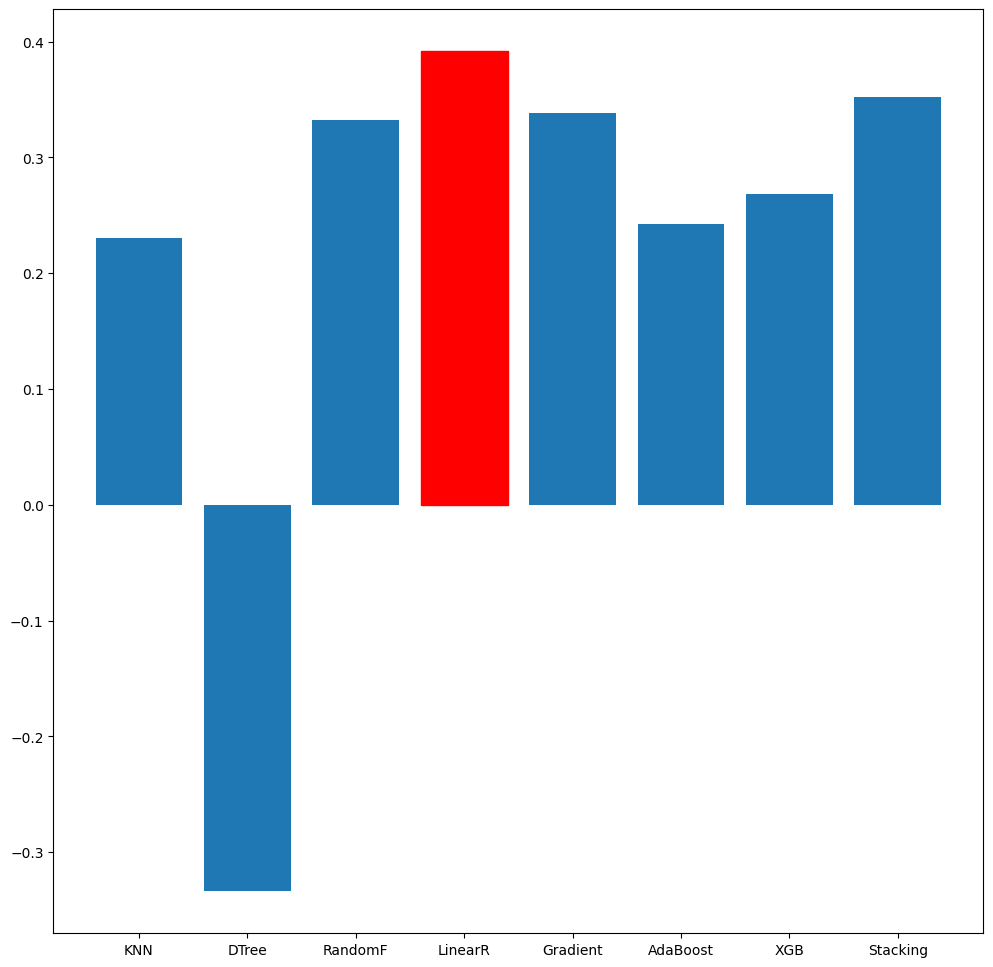

In [ ]:
mset=['KNN','DTree','RandomF','LinearR','Gradient','AdaBoost','XGB','Stacking']
mset
high=r.index(max(r))
plt.figure(figsize=(12,12))
bar=plt.bar(x=mset,height=r)
bar[high].set_color('red')

plt.show()

In [ ]:
params={'fit_intercept':[True,False],'copy_X':[True,False],'n_jobs':[1,2,3,4]}
gsc=GridSearchCV(LinearRegression(),params,cv=8,scoring=r2_score)
gsc.fit(x_tr,y_tr)
y_pred=gsc.predict(x_te)
warnings.filterwarnings('ignore')
print('r2:',r2_score(y_te,y_pred))
print('mse:',mean_absolute_error(y_te,y_pred))
print('rmse:',root_mean_squared_error(y_te,y_pred))
print('mae:',mean_absolute_error(y_te,y_pred))
gsc.best_params_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/inspect.py", line 3280, in bind
    return self._bind(args, kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/inspect.py", line 3204, in _bind
    raise TypeError(
TypeError: too many positional arguments

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_select

r2: 0.39172022837916204
mse: 0.7735587906281982
rmse: 0.9747471912398791
mae: 0.7735587906281982


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/inspect.py", line 3280, in bind
    return self._bind(args, kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/inspect.py", line 3204, in _bind
    raise TypeError(
TypeError: too many positional arguments

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_select

{'copy_X': True, 'fit_intercept': True, 'n_jobs': 1}

In [ ]:
lnr=LinearRegression(n_jobs=1)
lnr.fit(x_tr,y_tr)
y_lnr=lnr.predict(x_te)
print('r2:',r2_score(y_te,y_lnr))
print('mse:',mean_absolute_error(y_te,y_lnr))
print('rmse:',root_mean_squared_error(y_te,y_lnr))
print('mae:',mean_absolute_error(y_te,y_lnr))

r2: 0.39172022837916204
mse: 0.7735587906281982
rmse: 0.9747471912398791
mae: 0.7735587906281982


In [ ]:
y_val=lnr.predict(scaler.transform([[0,64,14,3,418,87,7,13,36,3,2,219,78,9,5,0.20]])).round().astype(int)
print(y_val)

[[2 1]]


In [ ]:
y_val[0][0]

np.int64(2)

In [ ]:
pickle.dump(lnr,open('model.sav','wb'))
pickle.dump(scaler,open('scaler.sav','wb'))

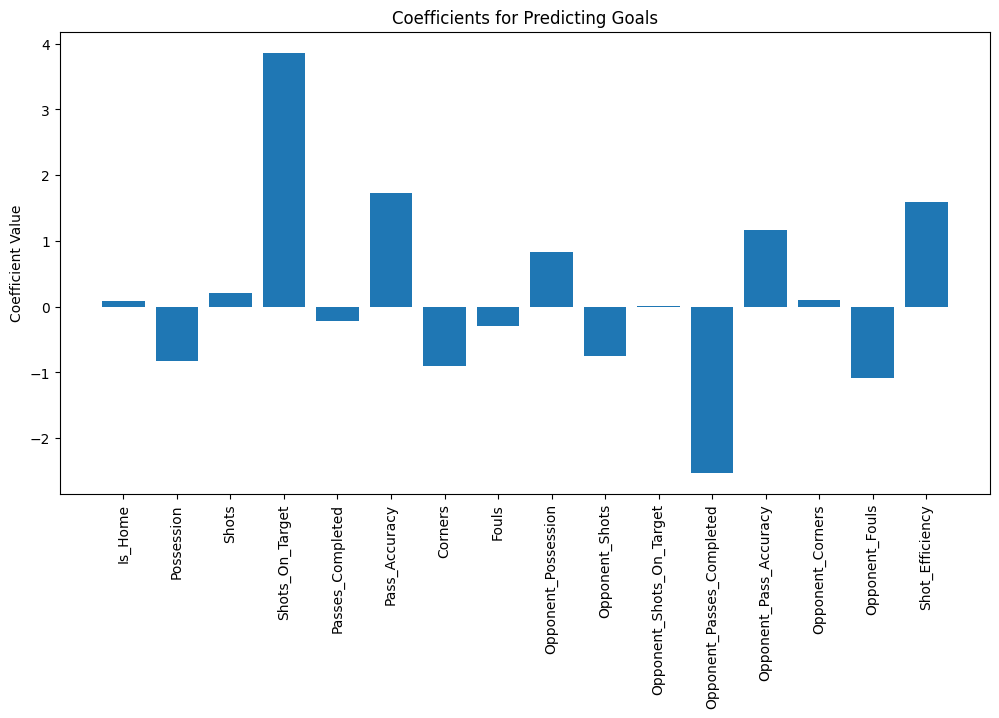

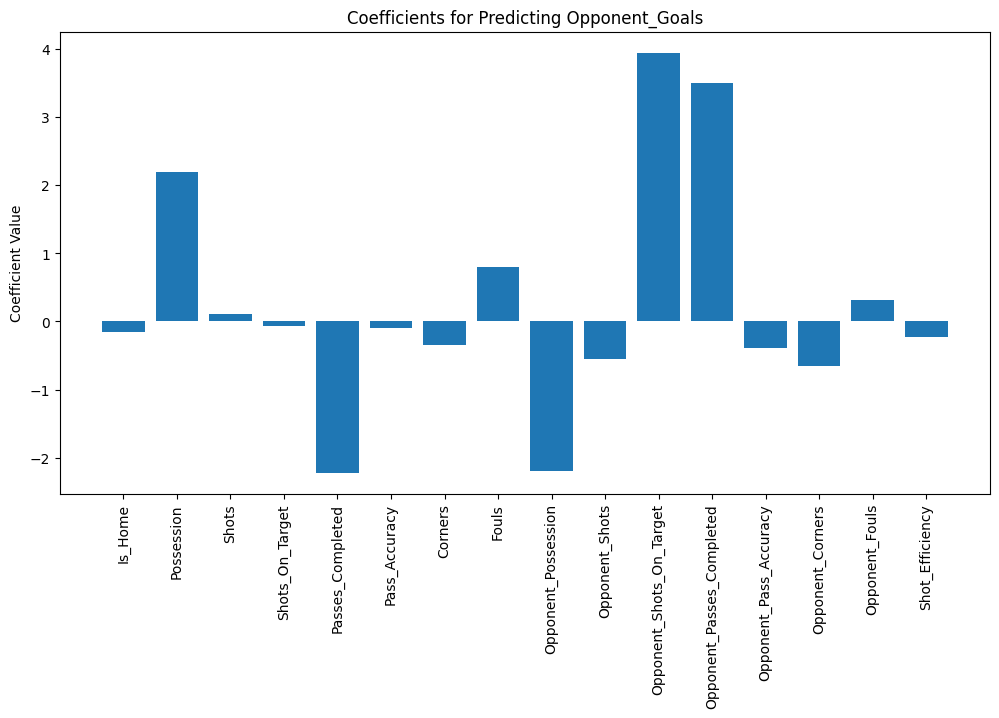

In [ ]:
features=['Is_Home','Possession','Shots','Shots_On_Target','Passes_Completed','Pass_Accuracy','Corners','Fouls',
          'Opponent_Possession','Opponent_Shots','Opponent_Shots_On_Target','Opponent_Passes_Completed','Opponent_Pass_Accuracy','Opponent_Corners',
          'Opponent_Fouls','Shot_Efficiency']


plt.figure(figsize=(12, 6))
plt.bar(features, lnr.coef_[0])
plt.xticks(rotation=90)
plt.title('Coefficients for Predicting Goals')
plt.ylabel('Coefficient Value')
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(features, lnr.coef_[1])
plt.xticks(rotation=90)
plt.title('Coefficients for Predicting Opponent_Goals')
plt.ylabel('Coefficient Value')
plt.show()